In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Superstore_Proper_Excel.xlsx to Superstore_Proper_Excel.xlsx


In [ ]:
# Load the Excel workbook
data = pd.ExcelFile("Superstore_Proper_Excel.xlsx")

data.sheet_names

['Read Me', 'Superstore Sales', 'People', 'Returns']

### Question 1

In [ ]:
# Business Data Overview

# Load the Sales sheet
df = pd.read_excel(data, sheet_name="Superstore Sales")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
# Check the dataset size

df.shape

(9994, 21)

In [ ]:
# Number of Orders

df["Order ID"].nunique()

5009

In [ ]:
# Number of Customers

df["Customer ID"].nunique()

793

In [ ]:
# Number of Products

df["Product ID"].nunique()

1862

In [ ]:
# Number of Categories

df["Category"].nunique()

3

In [ ]:
# Number of Sub-Categories

df["Sub-Category"].nunique()

17

In [ ]:
# Number of Regions

df["Region"].nunique()

4

In [ ]:
# Date Range

df["Order Date"].min()
df["Order Date"].max()

print("Start Date:", df["Order Date"].min())
print("End Date:", df["Order Date"].max())

Start Date: 2015-01-03 00:00:00
End Date: 2018-12-30 00:00:00


In [ ]:
# Load the Returns sheet

returns = pd.read_excel(data, sheet_name="Returns")

returns.head()

,Returned,Order ID
0,Yes,CA-2015-100762
1,Yes,CA-2015-100762
2,Yes,CA-2015-100762
3,Yes,CA-2015-100762
4,Yes,CA-2015-100867


In [ ]:
# Count Returned Orders

returns["Order ID"].nunique()

296

In [ ]:
# Create the Data Overview

data_overview = {
    "Total Transactions": len(df),
    "Total Orders": df["Order ID"].nunique(),
    "Total Customers": df["Customer ID"].nunique(),
    "Total Products": df["Product ID"].nunique(),
    "Total Categories": df["Category"].nunique(),
    "Total Sub-Categories": df["Sub-Category"].nunique(),
    "Total Regions": df["Region"].nunique(),
    "Start Date": df["Order Date"].min(),
    "End Date": df["Order Date"].max(),
    "Returned Orders": returns["Order ID"].nunique()
}

data_overview

{'Total Transactions': 9994,
 'Total Orders': 5009,
 'Total Customers': 793,
 'Total Products': 1862,
 'Total Categories': 3,
 'Total Sub-Categories': 17,
 'Total Regions': 4,
 'Start Date': Timestamp('2015-01-03 00:00:00'),
 'End Date': Timestamp('2018-12-30 00:00:00'),
 'Returned Orders': 296}

The Superstore dataset contains 9,994 transaction records representing 5,009 unique orders from 793 customers. The company sells 1,862 products across 3 categories and 17 sub-categories, operating across 4 regions. The sales data covers approximately four years, from January 2015 to December 2018. The Returns dataset contains 296 unique returned orders.

### Question 2  

In [ ]:
# Total Sales

total_sales = df["Sales"].sum()

total_sales
print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $2,297,200.86


In [ ]:
# Total Profit

total_profit = df["Profit"].sum()

total_profit
print(f"Total Profit: ${total_profit:,.2f}")

Total Profit: $286,397.02


In [ ]:
# Total Quantity Sold

total_quantity = df["Quantity"].sum()

total_quantity

print(f"Total Quantity Sold: {total_quantity:,}")

Total Quantity Sold: 37,873


In [ ]:
# Average Discount

average_discount = df["Discount"].mean()

average_discount
print(f"Average Discount: {average_discount:.2%}")

Average Discount: 15.62%


In [ ]:
# Average Sales per Order

average_sales_order = total_sales / df["Order ID"].nunique()

print(f"Average Sales per Order: ${average_sales_order:,.2f}")

Average Sales per Order: $458.61


In [ ]:
# Average Profit per Order

average_profit_order = total_profit / df["Order ID"].nunique()

print(f"Average Profit per Order: ${average_profit_order:,.2f}")

Average Profit per Order: $57.18


In [ ]:
# KPI Summary

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Average Discount: {average_discount:.2%}")
print(f"Average Sales per Order: ${average_sales_order:,.2f}")
print(f"Average Profit per Order: ${average_profit_order:,.2f}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Quantity Sold: 37,873
Average Discount: 15.62%
Average Sales per Order: $458.61
Average Profit per Order: $57.18


In [ ]:
# Overall Profit Margin

profit_margin = total_profit / total_sales

print(f"Overall Profit Margin: {profit_margin:.2%}")

Overall Profit Margin: 12.47%


The company generated \$2.30 million in sales and \$286,397 in profit, with a profit margin of 12.47%.

A total of 37,873 units were sold across 5,009 orders. Average sales per order were \$458.61 and average profit per order was \$57.18. The average discount was 15.62%.

Overall, the company is profitable. Further analysis is needed to identify products, regions, customers, and discounts that may be reducing profitability.

### Question 3

In [ ]:
# Product Performance

# Group by Category

category_performance = df.groupby("Category").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    quantity_sold=("Quantity", "sum")
)

category_performance

,total_sales,total_profit,quantity_sold
Category,,,
Furniture,741999.7953,18451.2728,8028
Office Supplies,719047.0320,122490.8008,22906
Technology,836154.0330,145454.9481,6939


In [ ]:
# Add Average Discount

category_performance = df.groupby("Category").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    quantity_sold=("Quantity", "sum"),
    average_discount=("Discount", "mean")
)

category_performance

,total_sales,total_profit,quantity_sold,average_discount
Category,,,,
Furniture,741999.7953,18451.2728,8028,0.173923
Office Supplies,719047.0320,122490.8008,22906,0.157285
Technology,836154.0330,145454.9481,6939,0.132323


In [ ]:
# Calculate Profit Margin

category_performance["profit_margin"] = (
    category_performance["total_profit"] /
    category_performance["total_sales"]
)

category_performance

,total_sales,total_profit,quantity_sold,average_discount,profit_margin
Category,,,,,
Furniture,741999.7953,18451.2728,8028,0.173923,0.024867
Office Supplies,719047.0320,122490.8008,22906,0.157285,0.170352
Technology,836154.0330,145454.9481,6939,0.132323,0.173957


In [ ]:
# Make the table easier to read

category_performance = category_performance.round({
    "total_sales": 2,
    "total_profit": 2,
    "quantity_sold": 0,
    "average_discount": 3,
    "profit_margin": 3
})

category_performance

,total_sales,total_profit,quantity_sold,average_discount,profit_margin
Category,,,,,
Furniture,741999.80,18451.27,8028,0.174,0.025
Office Supplies,719047.03,122490.80,22906,0.157,0.170
Technology,836154.03,145454.95,6939,0.132,0.174


In [ ]:
# Find highest and lowest performers

highest_sales_category = category_performance["total_sales"].idxmax()

print("Highest Sales Category:", highest_sales_category)

Highest Sales Category: Technology


In [ ]:
# Highest and Lowest Profit

highest_profit_category = category_performance["total_profit"].idxmax()
print("Highest Profit Category:", highest_profit_category)

lowest_profit_category = category_performance["total_profit"].idxmin()
print("Lowest Profit Category:", lowest_profit_category)

Highest Profit Category: Technology
Lowest Profit Category: Furniture


In [ ]:
# Analyse Sub-Categories Performance

subcategory_performance = df.groupby("Sub-Category").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    quantity_sold=("Quantity", "sum"),
    average_discount=("Discount", "mean")
)

subcategory_performance

,total_sales,total_profit,quantity_sold,average_discount
Sub-Category,,,,
Accessories,167380.3180,41936.6357,2976,0.078452
Appliances,107532.1610,18138.0054,1729,0.166524
Art,27118.7920,6527.7870,3000,0.074874
Binders,203412.7330,30221.7633,5974,0.372292
Bookcases,114879.9963,-3472.5560,868,0.211140
Chairs,328449.1030,26590.1663,2356,0.170178
Copiers,149528.0300,55617.8249,234,0.161765
Envelopes,16476.4020,6964.1767,906,0.080315
Fasteners,3024.2800,949.5182,914,0.082028


In [ ]:
# Add Sub-Category Profit Margin

subcategory_performance["profit_margin"] = (
    subcategory_performance["total_profit"] /
    subcategory_performance["total_sales"]
)

subcategory_performance

,total_sales,total_profit,quantity_sold,average_discount,profit_margin
Sub-Category,,,,,
Accessories,167380.3180,41936.6357,2976,0.078452,0.250547
Appliances,107532.1610,18138.0054,1729,0.166524,0.168675
Art,27118.7920,6527.7870,3000,0.074874,0.240711
Binders,203412.7330,30221.7633,5974,0.372292,0.148574
Bookcases,114879.9963,-3472.5560,868,0.211140,-0.030228
Chairs,328449.1030,26590.1663,2356,0.170178,0.080957
Copiers,149528.0300,55617.8249,234,0.161765,0.371956
Envelopes,16476.4020,6964.1767,906,0.080315,0.422676
Fasteners,3024.2800,949.5182,914,0.082028,0.313965


In [ ]:
# Loss-Making Sub-Categories

loss_making_subcategories = subcategory_performance[
    subcategory_performance["total_profit"] < 0
]

loss_making_subcategories

,total_sales,total_profit,quantity_sold,average_discount,profit_margin
Sub-Category,,,,,
Bookcases,114879.9963,-3472.5560,868,0.211140,-0.030228
Supplies,46673.5380,-1189.0995,647,0.076842,-0.025477
Tables,206965.5320,-17725.4811,1241,0.261285,-0.085645


In [ ]:
# Best Sub-Categories

highest_sales_subcategory = subcategory_performance["total_sales"].idxmax()

print("Highest Sales Sub-Category:", highest_sales_subcategory)

Highest Sales Sub-Category: Phones


In [ ]:
# Highest-Profit Sub-Category

highest_profit_subcategory = subcategory_performance["total_profit"].idxmax()

print("Highest Profit Sub-Category:", highest_profit_subcategory)

Highest Profit Sub-Category: Copiers


In [ ]:
# Lowest-Profit Sub-Category

lowest_profit_subcategory = subcategory_performance["total_profit"].idxmin()

print("Lowest Profit Sub-Category:", lowest_profit_subcategory)

Lowest Profit Sub-Category: Tables


In [ ]:
# Check Discounts for Poor-Performing Sub-Categories

loss_making_subcategories[
    ["total_sales", "total_profit", "average_discount", "profit_margin"]
]

,total_sales,total_profit,average_discount,profit_margin
Sub-Category,,,,
Bookcases,114879.9963,-3472.5560,0.211140,-0.030228
Supplies,46673.5380,-1189.0995,0.076842,-0.025477
Tables,206965.5320,-17725.4811,0.261285,-0.085645


Technology is the strongest category, generating the highest sales and profit. Office Supplies also performs well, while Furniture generates substantial sales but has a much lower profit margin.

At the sub-category level, Phones generate the highest sales, while Copiers generate the highest profit. Therefore, the products generating the highest revenue do not necessarily generate the highest profit.

Bookcases, Supplies, and Tables are loss-making sub-categories. Tables show the largest loss, with approximately \$206,966 in sales but a loss of about \$17,725. Tables and Bookcases also have relatively high average discounts, which may be contributing to their poor profitability.

These loss-making sub-categories, particularly Tables, should be investigated further.

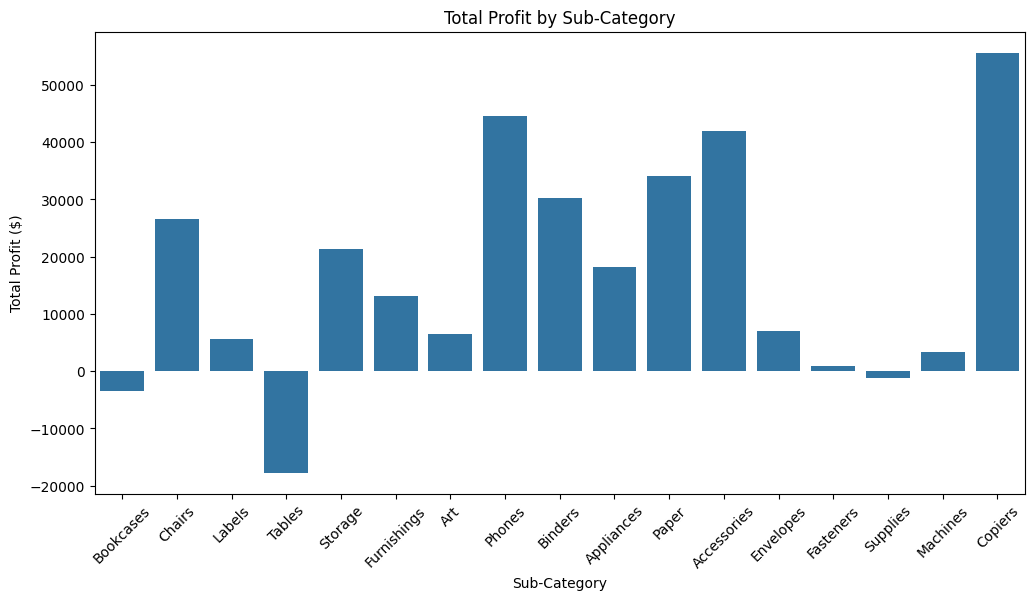

In [ ]:
# Visualise Sub-Category Profit

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x="Sub-Category",
    y="Profit",
    estimator=sum,
    errorbar=None
)

plt.title("Total Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit ($)")
plt.xticks(rotation=45)

plt.show()

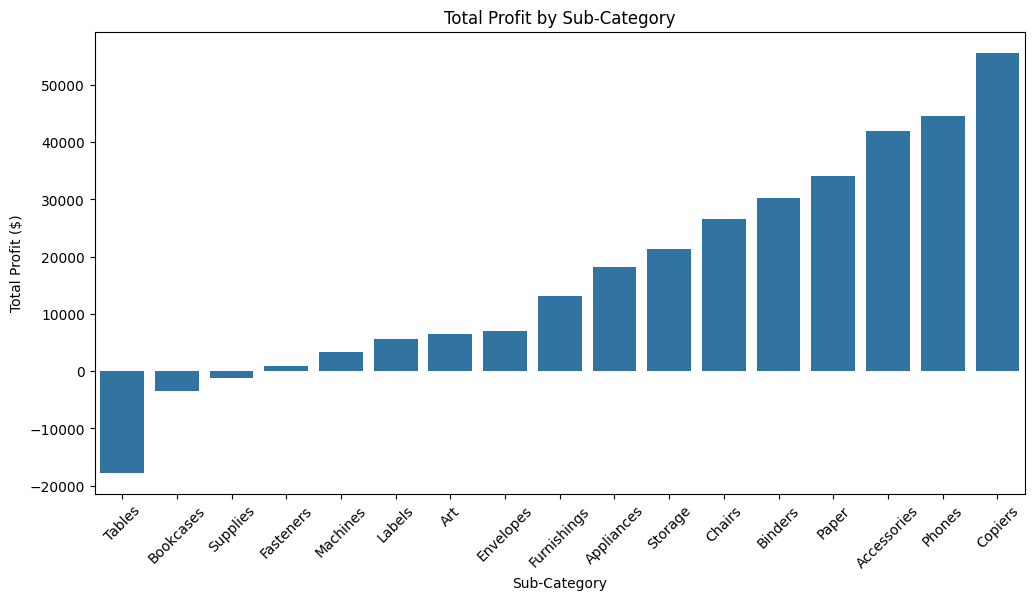

In [ ]:
# Sort the Chart

profit_order = (
    df.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values()
    .index
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x="Sub-Category",
    y="Profit",
    estimator=sum,
    errorbar=None,
    order=profit_order
)

plt.title("Total Profit by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Total Profit ($)")
plt.xticks(rotation=45)

plt.show()

### Question 4

In [ ]:
# Regional Performance

# Performance by Region

region_performance = df.groupby("Region").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    quantity_sold=("Quantity", "sum"),
    average_discount=("Discount", "mean")
)

region_performance

,total_sales,total_profit,quantity_sold,average_discount
Region,,,,
Central,501239.8908,39706.3625,8780,0.240353
East,678781.2400,91522.7800,10618,0.145365
South,391721.9050,46749.4303,6209,0.147253
West,725457.8245,108418.4489,12266,0.109335


In [ ]:
# Add Profit Margin

region_performance["profit_margin"] = (
    region_performance["total_profit"] /
    region_performance["total_sales"]
)

region_performance

,total_sales,total_profit,quantity_sold,average_discount,profit_margin
Region,,,,,
Central,501239.8908,39706.3625,8780,0.240353,0.079216
East,678781.2400,91522.7800,10618,0.145365,0.134834
South,391721.9050,46749.4303,6209,0.147253,0.119343
West,725457.8245,108418.4489,12266,0.109335,0.149448


In [ ]:
# Highest and Lowest Sales Regions

highest_sales_region = region_performance["total_sales"].idxmax()
lowest_sales_region = region_performance["total_sales"].idxmin()

print("Highest Sales Region:", highest_sales_region)
print("Lowest Sales Region:", lowest_sales_region)

Highest Sales Region: West
Lowest Sales Region: South


In [ ]:
# Highest and Lowest Profit Regions

highest_profit_region = region_performance["total_profit"].idxmax()
lowest_profit_region = region_performance["total_profit"].idxmin()

print("Highest Profit Region:", highest_profit_region)
print("Lowest Profit Region:", lowest_profit_region)

Highest Profit Region: West
Lowest Profit Region: Central


In [ ]:
# State-Level Performance

state_performance = df.groupby("State").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    quantity_sold=("Quantity", "sum"),
    average_discount=("Discount", "mean")
)

state_performance

,total_sales,total_profit,quantity_sold,average_discount
State,,,,
Alabama,19510.6400,5786.8253,256,0.000000
Arizona,35282.0010,-3427.9246,862,0.303571
Arkansas,11678.1300,4008.6871,240,0.000000
California,457687.6315,76381.3871,7667,0.072764
Colorado,32108.1180,-6527.8579,693,0.316484
Connecticut,13384.3570,3511.4918,281,0.007317
Delaware,27451.0690,9977.3748,367,0.006250
District of Columbia,2865.0200,1059.5893,40,0.000000
Florida,89473.7080,-3399.3017,1379,0.299347


In [ ]:
# Add Profit Margin

state_performance["profit_margin"] = (
    state_performance["total_profit"] /
    state_performance["total_sales"]
)


# Sort Values

state_performance.sort_values(
    "total_sales",
    ascending=False
).head(5)

,total_sales,total_profit,quantity_sold,average_discount,profit_margin
State,,,,,
California,457687.6315,76381.3871,7667,0.072764,0.166885
New York,310876.2710,74038.5486,4224,0.055319,0.238161
Texas,170188.0458,-25729.3563,3724,0.370193,-0.151182
Washington,138641.2700,33402.6517,1883,0.064032,0.240929
Pennsylvania,116511.9140,-15559.9603,2153,0.328620,-0.133548


In [ ]:
# Worst States by Profit

state_performance.sort_values(
    "total_profit"
).head()

,total_sales,total_profit,quantity_sold,average_discount,profit_margin
State,,,,,
Texas,170188.0458,-25729.3563,3724,0.370193,-0.151182
Ohio,78258.1360,-16971.3766,1759,0.324947,-0.216864
Pennsylvania,116511.9140,-15559.9603,2153,0.328620,-0.133548
Illinois,80166.1010,-12607.8870,1845,0.390041,-0.157272
North Carolina,55603.1640,-7490.9122,983,0.283534,-0.134721


`sort_values()` uses `ascending=True` by default.

- `ascending=True` → lowest to highest
- `ascending=False` → highest to lowest

In [ ]:
# Top 5 States by Profit

state_performance.sort_values(
    "total_profit",
    ascending=False
).head()

,total_sales,total_profit,quantity_sold,average_discount,profit_margin
State,,,,,
California,457687.6315,76381.3871,7667,0.072764,0.166885
New York,310876.2710,74038.5486,4224,0.055319,0.238161
Washington,138641.2700,33402.6517,1883,0.064032,0.240929
Michigan,76269.6140,24463.1876,946,0.007059,0.320746
Virginia,70636.7200,18597.9504,893,0.000000,0.263290


In [ ]:
# City-Level Performance

city_performance = df.groupby("City").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    quantity_sold=("Quantity", "sum"),
    average_discount=("Discount", "mean")
)

city_performance["profit_margin"] = (
    city_performance["total_profit"] /
    city_performance["total_sales"]
)


In [ ]:
city_performance.sort_values(
    "total_sales",
    ascending=False
).head()

,total_sales,total_profit,quantity_sold,average_discount,profit_margin
City,,,,,
New York City,256368.161,62036.9837,3417,0.056175,0.241984
Los Angeles,175851.341,30440.7579,2879,0.074297,0.173105
Seattle,119540.742,29156.0967,1590,0.064953,0.243901
San Francisco,112669.092,17507.3854,1935,0.066667,0.155388
Philadelphia,109077.013,-13837.7674,1981,0.326816,-0.126862


In [ ]:
# Cities with the Lowest Profit

city_performance.sort_values(
    "total_profit"
).head()

,total_sales,total_profit,quantity_sold,average_discount,profit_margin
City,,,,,
Philadelphia,109077.0130,-13837.7674,1981,0.326816,-0.126862
Houston,64504.7604,-10153.5485,1466,0.379682,-0.157408
San Antonio,21843.5280,-7299.0502,247,0.383051,-0.334152
Lancaster,9891.4640,-7239.0684,171,0.315217,-0.731850
Chicago,48539.5410,-6654.5688,1132,0.383758,-0.137096


In [ ]:
# Top Cities by Profit

city_performance.sort_values(
    "total_profit",
    ascending=False
).head()

,total_sales,total_profit,quantity_sold,average_discount,profit_margin
City,,,,,
New York City,256368.161,62036.9837,3417,0.056175,0.241984
Los Angeles,175851.341,30440.7579,2879,0.074297,0.173105
Seattle,119540.742,29156.0967,1590,0.064953,0.243901
San Francisco,112669.092,17507.3854,1935,0.066667,0.155388
Detroit,42446.944,13181.7908,441,0.006957,0.310547


In [ ]:
# High-Sales but Loss-Making Cities

loss_making_cities = city_performance[
    city_performance["total_profit"] < 0
]

loss_making_cities.sort_values(
    "total_sales",
    ascending=False
).head()

,total_sales,total_profit,quantity_sold,average_discount,profit_margin
City,,,,,
Philadelphia,109077.0130,-13837.7674,1981,0.326816,-0.126862
Houston,64504.7604,-10153.5485,1466,0.379682,-0.157408
Chicago,48539.5410,-6654.5688,1132,0.383758,-0.137096
Jacksonville,44713.1830,-2323.8350,429,0.286800,-0.051972
San Antonio,21843.5280,-7299.0502,247,0.383051,-0.334152


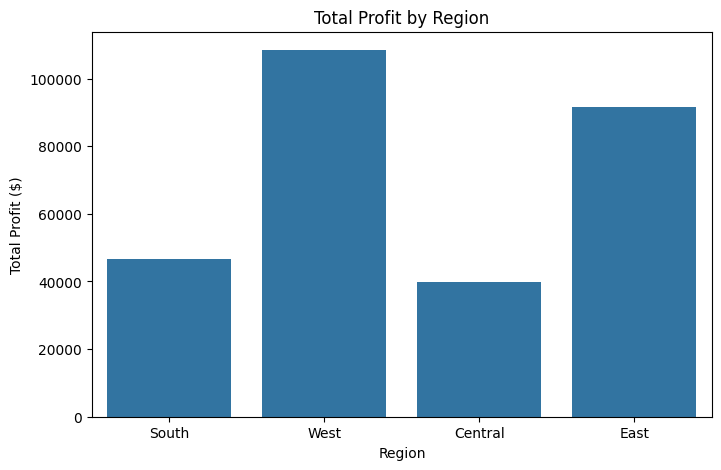

In [ ]:
# Regional Performance Chart

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Region",
    y="Profit",
    estimator=sum,
    errorbar=None
)

plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit ($)")

plt.show()

### Regional Performance Insights

The West is the strongest region, generating the highest sales and profit with a profit margin of about 14.9%. The Central region has the lowest profit and a lower profit margin of about 7.9%.

At the state level, California and New York generate strong sales and profits. In contrast, Texas and Pennsylvania generate high sales but operate at a loss.

At the city level, Philadelphia stands out with approximately \$109,077 in sales but a loss of about \$13,838. Houston and Chicago also generate substantial sales while remaining unprofitable.

These locations should be investigated further, particularly their discounting and product mix, to understand why strong sales are not translating into profit.

### Question 5

In [ ]:
# Customer Performance

# Create Customer Performance Table

customer_performance = df.groupby("Customer Name").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    number_of_orders=("Order ID", "nunique"),
    quantity_sold=("Quantity", "sum"),
    average_discount=("Discount", "mean")
)

customer_performance.head()

,total_sales,total_profit,number_of_orders,quantity_sold,average_discount
Customer Name,,,,,
Aaron Bergman,886.156,129.3465,3,13,0.066667
Aaron Hawkins,1744.700,365.2152,7,54,0.090909
Aaron Smayling,3050.692,-253.5746,7,48,0.355000
Adam Bellavance,7755.620,2054.5885,8,56,0.044444
Adam Hart,3250.337,281.1890,10,75,0.135000


In [ ]:
# Top 10 Customers by Sales

top_10_customers = customer_performance.sort_values(
    "total_sales",
    ascending=False
).head(10)

top_10_customers

,total_sales,total_profit,number_of_orders,quantity_sold,average_discount
Customer Name,,,,,
Sean Miller,25043.050,-1980.7393,5,50,0.246667
Tamara Chand,19052.218,8981.3239,5,42,0.116667
Raymond Buch,15117.339,6976.0959,6,71,0.094444
Tom Ashbrook,14595.620,4703.7883,4,36,0.080000
Adrian Barton,14473.571,5444.8055,10,73,0.240000
Ken Lonsdale,14175.229,806.8550,12,113,0.200000
Sanjit Chand,14142.334,5757.4119,9,87,0.063636
Hunter Lopez,12873.298,5622.4292,6,50,0.018182
Sanjit Engle,12209.438,2650.6769,11,78,0.110526


In [ ]:
# High-Sales but Loss-Making Customers

# Sean Miller has the highest sales at about $25,043, but actually generated a loss of about $1,981.
# So a high-sales customer is not necessarily a profitable customer.

loss_making_customers = customer_performance[
    customer_performance["total_profit"] < 0
]

loss_making_customers.sort_values(
    "total_sales",
    ascending=False
).head(10)

,total_sales,total_profit,number_of_orders,quantity_sold,average_discount
Customer Name,,,,,
Sean Miller,25043.050,-1980.7393,5,50,0.246667
Becky Martin,11789.630,-1659.9581,4,64,0.168750
Grant Thornton,9351.212,-4108.6589,3,26,0.250000
Peter Fuller,9062.864,-614.2943,4,75,0.121053
Natalie Fritzler,8322.826,-1695.9714,7,52,0.250000
Sean Braxton,8057.891,-2082.7451,7,84,0.241176
Zuschuss Carroll,8025.707,-1032.1490,13,105,0.254839
Joseph Holt,7954.998,-644.6982,6,64,0.085714
Joseph Airdo,6491.026,-819.4217,8,87,0.212500


total_profit < 0      → keep customers making a loss

ascending=False       → put highest-sales customers first

In [ ]:
# Top 10 Customers by Profit

top_profit_customers = customer_performance.sort_values(
    "total_profit",
    ascending=False
).head(10)

top_profit_customers

,total_sales,total_profit,number_of_orders,quantity_sold,average_discount
Customer Name,,,,,
Tamara Chand,19052.218,8981.3239,5,42,0.116667
Raymond Buch,15117.339,6976.0959,6,71,0.094444
Sanjit Chand,14142.334,5757.4119,9,87,0.063636
Hunter Lopez,12873.298,5622.4292,6,50,0.018182
Adrian Barton,14473.571,5444.8055,10,73,0.240000
Tom Ashbrook,14595.620,4703.7883,4,36,0.080000
Christopher Martinez,8954.020,3899.8904,4,34,0.120000
Keith Dawkins,8181.256,3038.6254,12,84,0.087500
Andy Reiter,6608.448,2884.6208,6,33,0.066667


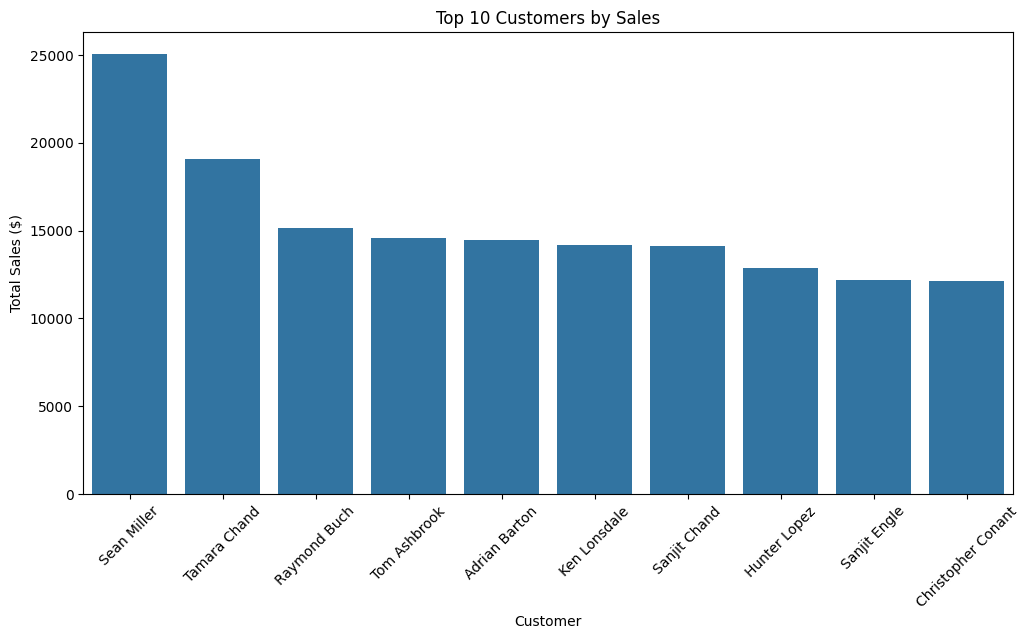

In [ ]:
# Visualise Top 10 Customers by Sales

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10_customers.reset_index(),
    x="Customer Name",
    y="total_sales"
)

plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)

plt.show()

### Customer Performance Insights

The highest-sales customer is Sean Miller, generating approximately \$25,043 in sales. However, this customer produced a loss of about \$1,981.

Tamara Chand is the most profitable customer, generating approximately \$8,981 in profit from \$19,052 in sales.

Several high-sales customers generate negative profit, showing that high customer spending does not always result in high profitability.

Customers such as Sean Miller and Grant Thornton should be investigated further to understand the reasons for their losses, including discounts and product purchases.

### Question 6

In [ ]:
# Discount & Profitability Analysis

# Check the Discount Values

sorted(df["Discount"].unique())

[np.float64(0.0),
 np.float64(0.1),
 np.float64(0.15),
 np.float64(0.2),
 np.float64(0.3),
 np.float64(0.32),
 np.float64(0.4),
 np.float64(0.45),
 np.float64(0.5),
 np.float64(0.6),
 np.float64(0.7),
 np.float64(0.8)]

0.0 = 0%

0.1 = 10%

0.2 = 20%

In [ ]:
# Create Discount Groups

df["Discount_Group"] = pd.cut(
    df["Discount"],
    bins=[-0.01, 0.1, 0.2, 0.3, 0.5, 0.8],
    labels=["0–10%", "11–20%", "21–30%", "31–50%", "51–80%"]
)

df[["Discount", "Discount_Group"]].head()

,Discount,Discount_Group
0,0.00,0–10%
1,0.00,0–10%
2,0.00,0–10%
3,0.45,31–50%
4,0.20,11–20%


0.45 means a 45% discount, so it correctly goes into the 31–50% group.

In [ ]:
# Analyse Each Discount Group

discount_performance = df.groupby(
    "Discount_Group",
    observed=True
).agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    average_profit=("Profit", "mean"),
    number_of_orders=("Order ID", "nunique")
)

discount_performance

,total_sales,total_profit,average_profit,number_of_orders
Discount_Group,,,,
0–10%,1.142278e+06,330016.7802,67.460503,2679
11–20%,7.921529e+05,91756.2975,24.738824,2436
21–30%,1.032267e+05,-10369.2774,-45.679636,211
31–50%,1.953148e+05,-48447.7273,-156.282991,280
51–80%,6.422874e+04,-76559.0513,-89.438144,685


In [ ]:
 # Check Discount vs Profit Directly

 discount_profit = df.groupby("Discount").agg(
    average_profit=("Profit", "mean"),
    total_profit=("Profit", "sum")
)

discount_profit

,average_profit,total_profit
Discount,,
0.00,66.900292,320987.6032
0.10,96.055074,9029.1770
0.15,27.288298,1418.9915
0.20,24.702572,90337.3060
0.30,-45.679636,-10369.2774
0.32,-88.560656,-2391.1377
0.40,-111.927429,-23057.0504
0.45,-226.646464,-2493.1111
0.50,-310.703456,-20506.4281


total_profit   → How much money did the business gain/lose overall?

average_profit → On average, how profitable was each transaction?


50% discount → Average profit = -$310.70
               Total profit   = -$20,506

70% discount → Average profit = -$95.87
               Total profit   = -$40,075

In [ ]:
# Find High-Discount, Loss-Making Sub-Categories

# Use 30%+ because profit becomes negative from the 30% discount level onwards
high_discount = df[df["Discount"] >= 0.30]

high_discount_subcategories = high_discount.groupby("Sub-Category").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    average_discount=("Discount", "mean")
)

high_discount_subcategories.sort_values("total_profit").head()

,total_sales,total_profit,average_discount
Sub-Category,,,
Binders,36140.6130,-38510.4964,0.738010
Tables,89956.5400,-30698.2228,0.392898
Machines,76839.1080,-29555.3521,0.543396
Bookcases,28543.9988,-11097.7614,0.444857
Appliances,3382.5340,-8629.6412,0.800000


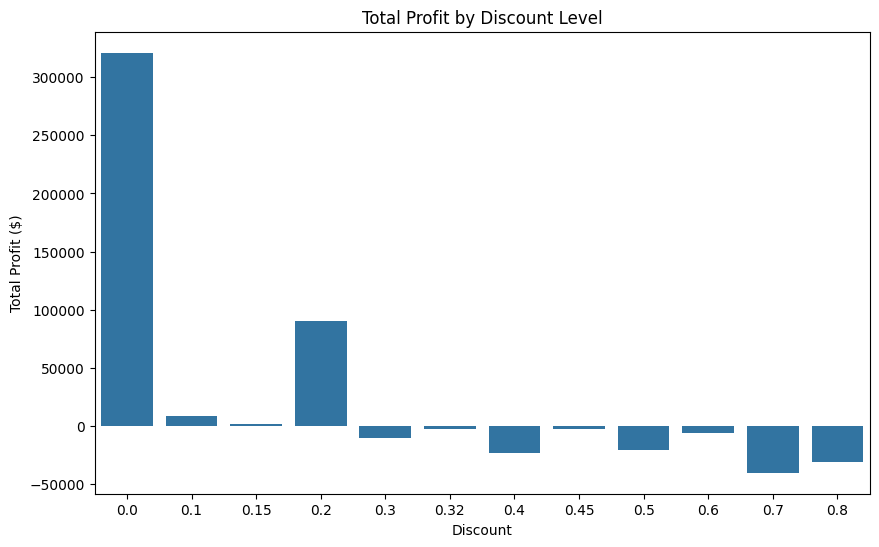

In [ ]:
# Visualise Discount vs Profit

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="Discount",
    y="Profit",
    estimator=sum,
    errorbar=None
)

plt.title("Total Profit by Discount Level")
plt.xlabel("Discount")
plt.ylabel("Total Profit ($)")

plt.show()

### Discount & Profitability Insights

Profitability decreases as discount levels increase.

Discounts up to 20% generate positive profit, while discount levels of 30% and above are associated with losses. The 70% discount level produces the largest total loss.

Among high-discount transactions, Binders, Tables, and Machines generate the largest losses.

This suggests that high discounting may be reducing profitability and should be investigated, particularly for these sub-categories.

### Question 7

In [ ]:
# Shipping Performance

# Create Shipping Performance Table

shipping_performance = df.groupby("Ship Mode").agg(
    number_of_orders=("Order ID", "nunique"),
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    quantity_sold=("Quantity", "sum")
)

shipping_performance

,number_of_orders,total_sales,total_profit,quantity_sold
Ship Mode,,,,
First Class,787,3.514284e+05,48969.8399,5693
Same Day,264,1.283631e+05,15891.7589,1960
Second Class,964,4.591936e+05,57446.6354,7423
Standard Class,2994,1.358216e+06,164088.7875,22797


In [ ]:
# Average Sales per Order

shipping_performance["average_sales_per_order"] = (
    shipping_performance["total_sales"] /
    shipping_performance["number_of_orders"]
)

shipping_performance

,number_of_orders,total_sales,total_profit,quantity_sold,average_sales_per_order
Ship Mode,,,,,
First Class,787,3.514284e+05,48969.8399,5693,446.541833
Same Day,264,1.283631e+05,15891.7589,1960,486.223958
Second Class,964,4.591936e+05,57446.6354,7423,476.341877
Standard Class,2994,1.358216e+06,164088.7875,22797,453.645873


In [ ]:
# Confirm Highest Volume and Profit

highest_volume = shipping_performance["number_of_orders"].idxmax()
highest_profit = shipping_performance["total_profit"].idxmax()
highest_avg_sales = shipping_performance["average_sales_per_order"].idxmax()

print("Highest Order Volume:", highest_volume)
print("Highest Total Profit:", highest_profit)
print("Highest Average Sales per Order:", highest_avg_sales)

Highest Order Volume: Standard Class
Highest Total Profit: Standard Class
Highest Average Sales per Order: Same Day


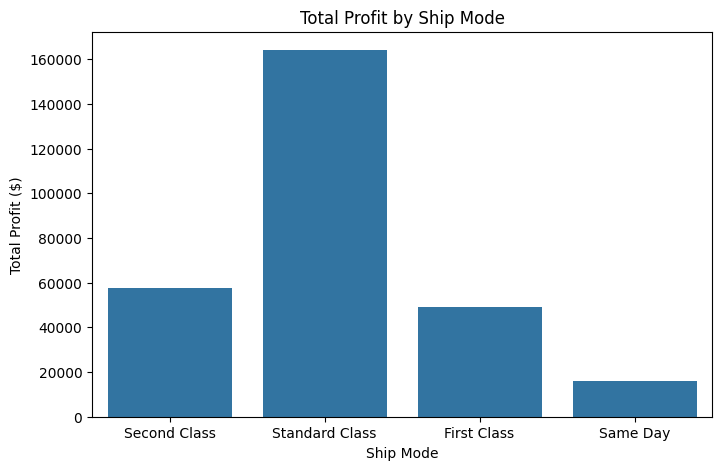

In [ ]:
# Shipping Profit Chart

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Ship Mode",
    y="Profit",
    estimator=sum,
    errorbar=None
)

plt.title("Total Profit by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Total Profit ($)")

plt.show()


### Shipping Performance Insights

Standard Class is the most frequently used shipping mode with 2,994 orders. It also generates the highest total sales and profit.

Same Day has the highest average sales per order at approximately \$486.

Overall, Standard Class is the most important shipping mode because it handles the highest order volume and generates the highest total profit.

### Question 8

In [ ]:
# Customer Segment Performance

# Create Segment Performance Table

segment_performance = df.groupby("Segment").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    quantity_sold=("Quantity", "sum"),
    customer_count=("Customer ID", "nunique"),
    number_of_orders=("Order ID", "nunique")
)

segment_performance

,total_sales,total_profit,quantity_sold,customer_count,number_of_orders
Segment,,,,,
Consumer,1.161401e+06,134119.2092,19521,409,2586
Corporate,7.061464e+05,91979.1340,11608,236,1514
Home Office,4.296531e+05,60298.6785,6744,148,909


In [ ]:
# Calculate Average Order Value

segment_performance["average_order_value"] = (
    segment_performance["total_sales"] /
    segment_performance["number_of_orders"]
)

segment_performance

,total_sales,total_profit,quantity_sold,customer_count,number_of_orders,average_order_value
Segment,,,,,,
Consumer,1.161401e+06,134119.2092,19521,409,2586,449.111116
Corporate,7.061464e+05,91979.1340,11608,236,1514,466.411075
Home Office,4.296531e+05,60298.6785,6744,148,909,472.665730


In [ ]:
# Calculate Profit Margin

segment_performance["profit_margin"] = (
    segment_performance["total_profit"] /
    segment_performance["total_sales"]
) * 100

segment_performance

,total_sales,total_profit,quantity_sold,customer_count,number_of_orders,average_order_value,profit_margin
Segment,,,,,,,
Consumer,1.161401e+06,134119.2092,19521,409,2586,449.111116,11.548050
Corporate,7.061464e+05,91979.1340,11608,236,1514,466.411075,13.025506
Home Office,4.296531e+05,60298.6785,6744,148,909,472.665730,14.034269


In [ ]:
# Confirm Customer Segment Performance

highest_sales_segment = segment_performance["total_sales"].idxmax()
highest_profit_segment = segment_performance["total_profit"].idxmax()
highest_margin_segment = segment_performance["profit_margin"].idxmax()

print("Highest Sales Segment:", highest_sales_segment)
print("Highest Profit Segment:", highest_profit_segment)
print("Highest Profit Margin Segment:", highest_margin_segment)

Highest Sales Segment: Consumer
Highest Profit Segment: Consumer
Highest Profit Margin Segment: Home Office


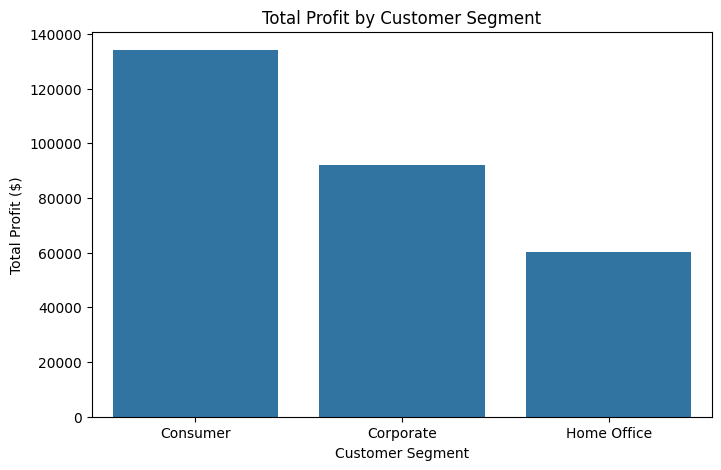

In [ ]:
# Segment Profit Chart

plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Segment",
    y="Profit",
    estimator=sum,
    errorbar=None
)

plt.title("Total Profit by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Profit ($)")

plt.show()

### Customer Segment Performance Insights

The Consumer segment is the largest and most important segment overall, generating approximately \$1.16 million in sales and \$134,119 in profit.

Consumer has both the highest total sales and the highest total profit, so the top-performing segment is the same for both measures.

However, Home Office has the highest average order value at approximately \$472.67 and the highest profit margin at 14.03%.

Overall, Consumer contributes the most to total business performance, while Home Office is more profitable relative to its sales.

### Question 9

In [ ]:
# Time-Based Performance

# Check the Order Date

df["Order Date"].dtype

dtype('<M8[ns]')

"Order Date" is already stored correctly as a date/time column.

dtype('<M8[ns]') means the same thing as:

datetime64[ns]

In [ ]:
# Create Year and Month Columns

df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

df[["Order Date", "Year", "Month"]].head()

,Order Date,Year,Month
0,2017-11-08,2017,11
1,2017-11-08,2017,11
2,2017-06-12,2017,6
3,2016-10-11,2016,10
4,2016-10-11,2016,10


In [ ]:
# Analyse Performance by Year

year_performance = df.groupby("Year").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum")
)

year_performance

,total_sales,total_profit
Year,,
2015,484247.4981,49543.9741
2016,470532.5090,61618.6037
2017,609205.5980,81795.1743
2018,733215.2552,93439.2696


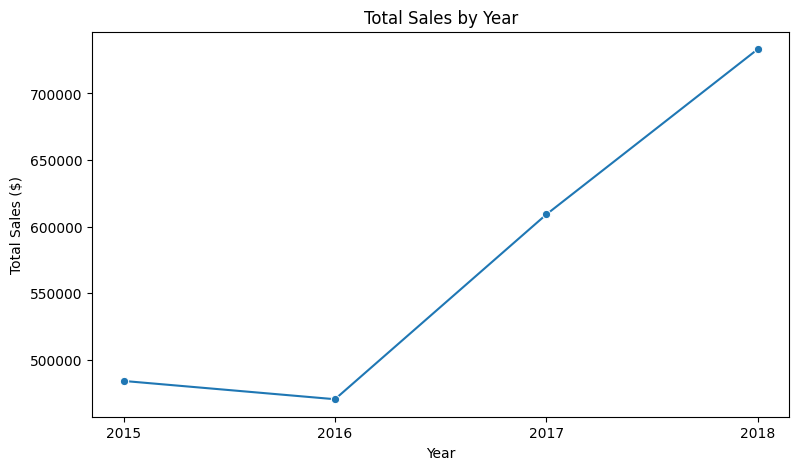

In [ ]:
# Yearly Sales & Profit Chart

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=year_performance,
    x=year_performance.index,
    y="total_sales",
    marker="o"
)

plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales ($)")
plt.xticks(year_performance.index)

plt.show()

In [ ]:
# Analyse by Month

monthly_performance = df.groupby(["Year", "Month"]).agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum")
).reset_index()

monthly_performance.head(12)

,Year,Month,total_sales,total_profit
0,2015,1,14236.8950,2450.1907
1,2015,2,4519.8920,862.3084
2,2015,3,55691.0090,498.7299
3,2015,4,28295.3450,3488.8352
4,2015,5,23648.2870,2738.7096
5,2015,6,34595.1276,4976.5244
6,2015,7,33946.3930,-841.4826
7,2015,8,27909.4685,5318.1050
8,2015,9,81777.3508,8328.0994
9,2015,10,31453.3930,3448.2573


In [ ]:
# Create a Proper Date for the Monthly Trend

monthly_performance["Date"] = pd.to_datetime(
    monthly_performance[["Year", "Month"]].assign(DAY=1)
)

monthly_performance.head()


,Year,Month,total_sales,total_profit,Date
0,2015,1,14236.895,2450.1907,2015-01-01
1,2015,2,4519.892,862.3084,2015-02-01
2,2015,3,55691.009,498.7299,2015-03-01
3,2015,4,28295.345,3488.8352,2015-04-01
4,2015,5,23648.287,2738.7096,2015-05-01


Creating a Date Column

- `monthly_performance[["Year", "Month"]]` → selects Year and Month.
- `.assign(DAY=1)` → adds day 1 because a complete date needs Year, Month, and Day.
- `pd.to_datetime()` → combines them into a proper date, e.g. `2015-01-01`.
- `monthly_performance["Date"]` → stores the result in a new Date column.


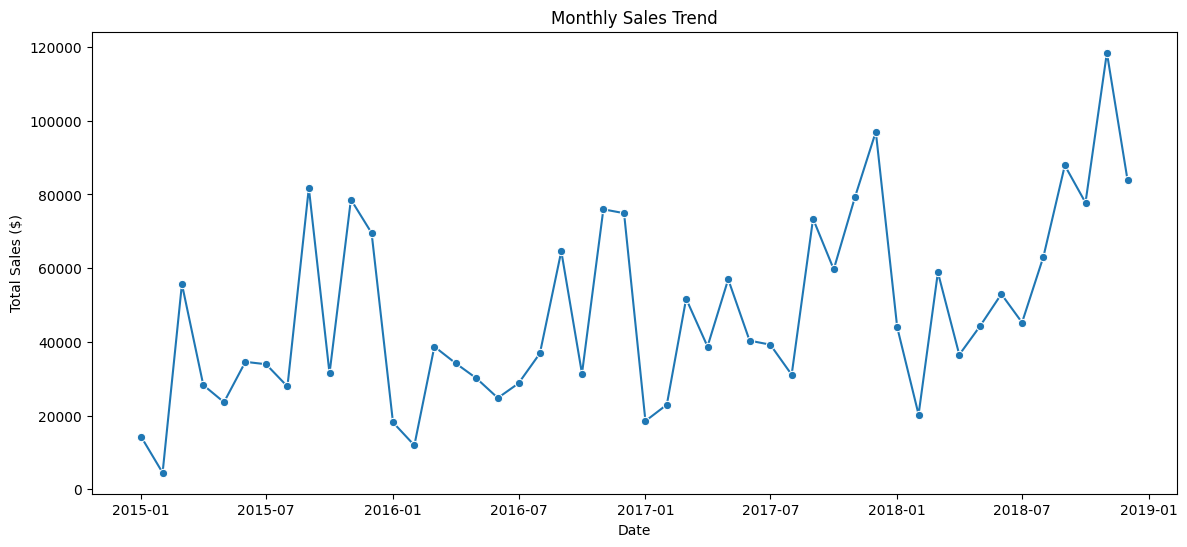

In [ ]:
# Visualize Monthly Sales Trend

# Create the figure
plt.figure(figsize=(14, 6))

# Plot total sales over time
sns.lineplot(
    data=monthly_performance,
    x="Date",
    y="total_sales",
    marker="o"
)

# Add chart title
plt.title("Monthly Sales Trend")

# Add axis labels
plt.xlabel("Date")
plt.ylabel("Total Sales ($)")

# Display the chart
plt.show()

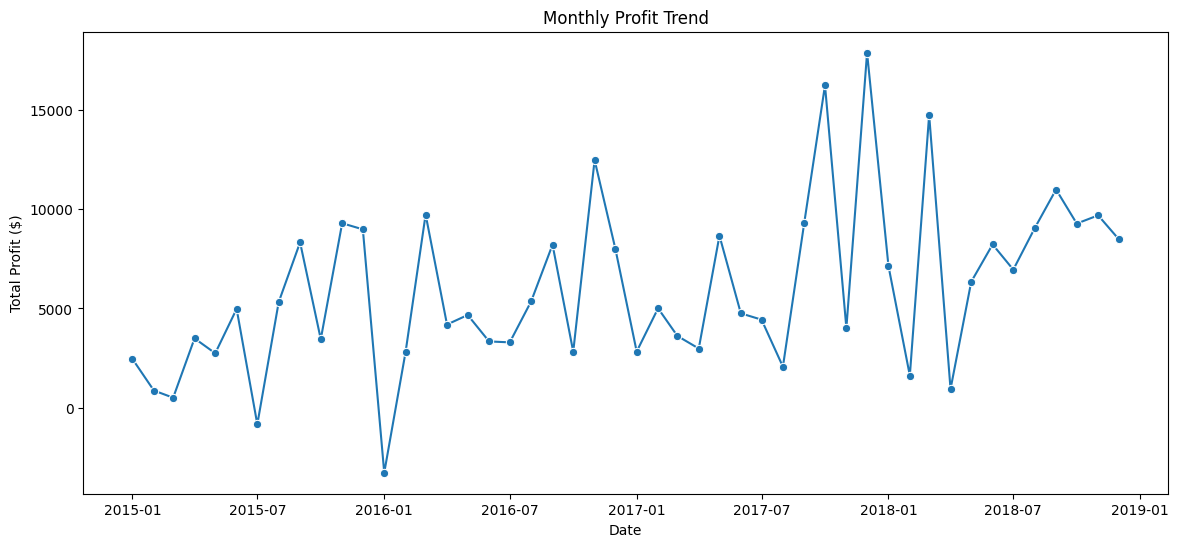

In [ ]:
# Visualize Monthly Profit Trend

# Create the figure
plt.figure(figsize=(14, 6))

# Plot total profit over time
sns.lineplot(
    data=monthly_performance,
    x="Date",
    y="total_profit",
    marker="o"
)

# Add chart title
plt.title("Monthly Profit Trend")

# Add axis labels
plt.xlabel("Date")
plt.ylabel("Total Profit ($)")

# Display the chart
plt.show()

.idxmax() → finds the row position of the highest value

.idxmin() → finds the row position of the lowest value

.loc[]    → retrieves the whole row

In [ ]:
# Find the Best and Worst Months

# Find the month with the highest sales
highest_sales_month = monthly_performance.loc[
    monthly_performance["total_sales"].idxmax()
]

# Find the month with the highest profit
highest_profit_month = monthly_performance.loc[
    monthly_performance["total_profit"].idxmax()
]

# Find the month with the lowest profit
lowest_profit_month = monthly_performance.loc[
    monthly_performance["total_profit"].idxmin()
]

print("Highest Sales Month:")
print(highest_sales_month)

print("\nHighest Profit Month:")
print(highest_profit_month)

print("\nLowest Profit Month:")
print(lowest_profit_month)

Highest Sales Month:
Year                           2018
Month                            11
total_sales              118447.825
total_profit              9690.1037
Date            2018-11-01 00:00:00
Name: 46, dtype: object

Highest Profit Month:
Year                           2017
Month                            12
total_sales               96999.043
total_profit             17885.3093
Date            2017-12-01 00:00:00
Name: 35, dtype: object

Lowest Profit Month:
Year                           2016
Month                             1
total_sales              18174.0756
total_profit              -3281.007
Date            2016-01-01 00:00:00
Name: 12, dtype: object


.idxmax() → finds the row position of the highest value

.idxmin() → finds the row position of the lowest value

.loc[]    → retrieves the whole row

- Highest sales: November 2018 — \$118,447.83
- Highest profit: December 2017 — \$17,885.31
- Lowest profit: January 2016 — -\$3,281.01

In [ ]:
# Find Months with Negative Profit

# Select months where total profit is negative
loss_months = monthly_performance[
    monthly_performance["total_profit"] < 0
]

# Show the loss-making months
loss_months

,Year,Month,total_sales,total_profit,Date
6,2015,7,33946.3930,-841.4826,2015-07-01
12,2016,1,18174.0756,-3281.0070,2016-01-01


In [ ]:
# Check Sales Growth vs Profit Growth

# Calculate month-to-month percentage change in sales
monthly_performance["sales_change"] = (
    monthly_performance["total_sales"].pct_change() * 100
)

# Calculate month-to-month percentage change in profit
monthly_performance["profit_change"] = (
    monthly_performance["total_profit"].pct_change() * 100
)

# Display the results
monthly_performance[
    ["Date", "total_sales", "total_profit", "sales_change", "profit_change"]
].head(10)

,Date,total_sales,total_profit,sales_change,profit_change
0,2015-01-01,14236.8950,2450.1907,NaN,NaN
1,2015-02-01,4519.8920,862.3084,-68.252263,-64.806478
2,2015-03-01,55691.0090,498.7299,1132.131409,-42.163395
3,2015-04-01,28295.3450,3488.8352,-49.192257,599.544022
4,2015-05-01,23648.2870,2738.7096,-16.423401,-21.500746
5,2015-06-01,34595.1276,4976.5244,46.290205,81.710554
6,2015-07-01,33946.3930,-841.4826,-1.875220,-116.909042
7,2015-08-01,27909.4685,5318.1050,-17.783699,-731.992272
8,2015-09-01,81777.3508,8328.0994,193.009345,56.599003
9,2015-10-01,31453.3930,3448.2573,-61.537770,-58.594907


In [ ]:
# Find Sales-Up, Profit-Down Months

# Find months where sales increased but profit decreased
sales_up_profit_down = monthly_performance[
    (monthly_performance["sales_change"] > 0) &
    (monthly_performance["profit_change"] < 0)
]

# Show the important columns
sales_up_profit_down[
    ["Date", "total_sales", "total_profit", "sales_change", "profit_change"]
]

,Date,total_sales,total_profit,sales_change,profit_change
2,2015-03-01,55691.0090,498.7299,1132.131409,-42.163395
18,2016-07-01,28765.3250,3288.6483,16.001880,-1.406329
26,2017-03-01,51715.8750,3611.9680,125.058929,-27.826743
34,2017-11-01,79411.9658,4011.4075,33.045679,-75.303994


Sales Growth vs Profit Growth

Some months had higher sales but lower profit:

1. March 2015: Sales +1132.13%, Profit -42.16%
2. July 2016: Sales +16.00%, Profit -1.41%
3. March 2017: Sales +125.06%, Profit -27.83%
4. November 2017: Sales +33.05%, Profit -75.30%



### Time-Based Performance Insights

Overall business performance improved over time. Sales and profit increased strongly after 2016, with 2018 recording the highest annual sales and profit.

November 2018 had the highest monthly sales at \$118,447.83, while December 2017 had the highest monthly profit at \$17,885.31.

Only two months generated an overall loss: July 2015 and January 2016. January 2016 had the largest monthly loss at \$3,281.01.

Sales growth did not always result in profit growth. For example, in November 2017, sales increased by approximately 33%, while profit decreased by approximately 75%.

Overall, the business shows a positive long-term growth trend, but monthly profitability fluctuates considerably and does not always move with sales.

### Question 10

In [ ]:
# Return Analysis

# Load the Return Sheet in excel file

returns = pd.read_excel(data, sheet_name="Returns")

In [ ]:
# Mark Returned Orders

# Mark each transaction as returned or not returned
df["Returned"] = df["Order ID"].isin(
    returns["Order ID"]
)

# Check the result
df[["Order ID", "Returned"]].head()

,Order ID,Returned
0,CA-2017-152156,False
1,CA-2017-152156,False
2,CA-2017-138688,False
3,US-2016-108966,False
4,US-2016-108966,False


In [ ]:
# Calculate the Return Rate

# Count total unique orders
total_orders = df["Order ID"].nunique()

# Count unique returned orders
returned_orders = df.loc[
    df["Returned"], "Order ID"
].nunique()

# Calculate return rate
return_rate = (returned_orders / total_orders) * 100

print(f"Total Orders: {total_orders:,}")
print(f"Returned Orders: {returned_orders:,}")
print(f"Return Rate: {return_rate:.2f}%")


Total Orders: 5,009
Returned Orders: 296
Return Rate: 5.91%


In [ ]:
# Returns by Category

# Keep only returned transactions
returned_data = df[df["Returned"]].copy()

# Count unique returned orders by category
category_returns = returned_data.groupby("Category").agg(
    returned_orders=("Order ID", "nunique"),
    returned_sales=("Sales", "sum"),
    returned_profit=("Profit", "sum")
)

category_returns

,returned_orders,returned_sales,returned_profit
Category,,,
Furniture,136,59219.1749,2341.1187
Office Supplies,234,48576.9290,6893.8960
Technology,123,72708.1740,13997.3468


In [ ]:
# Calculate Return Rate by Category

# Count total unique orders in each category
category_total_orders = df.groupby("Category")["Order ID"].nunique()

# Calculate return rate for each category
category_returns["return_rate"] = (
    category_returns["returned_orders"] /
    category_total_orders
) * 100

category_returns

,returned_orders,returned_sales,returned_profit,return_rate
Category,,,,
Furniture,136,59219.1749,2341.1187,7.709751
Office Supplies,234,48576.9290,6893.8960,6.253340
Technology,123,72708.1740,13997.3468,7.966321


Return rates

- Technology: 7.97% — highest return rate
- Furniture: 7.71%
- Office Supplies: 6.25% — lowest return rate

In [ ]:
# Returns by Region

# Count returned orders by region
region_returns = returned_data.groupby("Region").agg(
    returned_orders=("Order ID", "nunique"),
    returned_sales=("Sales", "sum"),
    returned_profit=("Profit", "sum")
)

# Count total orders by region
region_total_orders = df.groupby("Region")["Order ID"].nunique()

# Calculate return rate
region_returns["return_rate"] = (
    region_returns["returned_orders"] /
    region_total_orders
) * 100

region_returns

,returned_orders,returned_sales,returned_profit,return_rate
Region,,,,
Central,39,14006.9794,-3634.4274,3.319149
East,44,41705.1440,4984.8006,3.140614
South,24,17309.0970,2218.6105,2.919708
West,189,107483.0575,19663.3778,11.731844


- West - 189 returned orders, 11.73% return rate — much higher than every other region
- Central: 3.32%
- East: 3.14%
- South: 2.92%

Central has negative profit (-$3,634.43) associated with returned transactions, while the other regions are positive.

In [ ]:
# Check Returns by Sub-Category

# Analyse returns by sub-category
subcategory_returns = returned_data.groupby("Sub-Category").agg(
    returned_orders=("Order ID", "nunique"),
    returned_sales=("Sales", "sum"),
    returned_profit=("Profit", "sum")
)

# Count total orders in each sub-category
subcategory_total_orders = df.groupby("Sub-Category")["Order ID"].nunique()

# Calculate return rate
subcategory_returns["return_rate"] = (
    subcategory_returns["returned_orders"] /
    subcategory_total_orders
) * 100

# Sort from highest to lowest return rate
subcategory_returns.sort_values(
    "return_rate",
    ascending=False
)

,returned_orders,returned_sales,returned_profit,return_rate
Sub-Category,,,,
Machines,13,13158.3900,-262.7283,11.607143
Tables,30,17042.2820,-1058.0824,9.771987
Appliances,40,10129.7820,2571.6706,8.869180
Fasteners,19,213.0900,91.7360,8.837209
Phones,71,27633.6140,2780.9066,8.722359
Supplies,16,3195.9620,120.6558,8.556150
Paper,99,7140.2820,3237.0991,8.312343
Binders,108,9983.1490,-1802.2774,8.206687
Chairs,47,25154.7020,1207.0228,8.159722


- Machines have the highest return rate: 11.61%
- Tables are second: 9.77%
- Binders have the most returned orders: 108
- Machines, Tables, and Binders also have negative profit associated with returned transactions
- Tables are especially interesting because we already found in Q3 that they are a major loss-making sub-category.

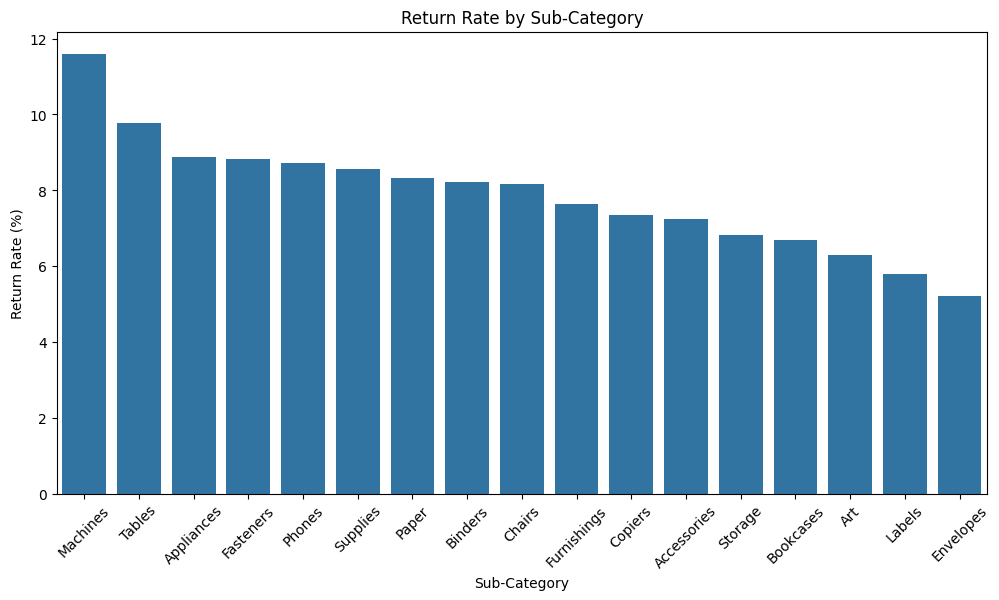

In [ ]:
# Visualise Return Rate by Sub-Category

# Sort sub-categories by return rate
return_rate_order = (
    subcategory_returns
    .sort_values("return_rate", ascending=False)
    .index
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=subcategory_returns.reset_index(),
    x="Sub-Category",
    y="return_rate",
    order=return_rate_order
)

plt.title("Return Rate by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)

plt.show()

### Returns Analysis Insights

The overall order return rate is 5.91%, with 296 returned orders out of 5,009 total orders.

Technology has the highest category return rate at 7.97%, followed by Furniture at 7.71%. Office Supplies has the most returned orders, but a lower return rate of 6.25%.

The West region has the highest return rate at 11.73%, which is considerably higher than the other regions.

At the sub-category level, Machines have the highest return rate at 11.61%, followed by Tables at 9.77%. Binders have the highest number of returned orders.

Machines, Tables, and Binders also show negative profit associated with returned transactions.

Overall, the West region and high-return sub-categories such as Machines and Tables should be investigated further to understand the reasons for returns and their impact on profitability.